In [4]:
# CELL 1: Setup (shared across all experiments)
import sys
sys.path.insert(0, "..")

from data_setup import load_all
from gru4rec import load_gru4rec, make_gru4rec_p_like, probe_fatigue_curve, paired_fatigue_probe
from env import FinalMovieRecEnvV6
from baselines import EpisodeRewardCallback
from evaluate import run_full_evaluation, print_results_table, run_ttest
from stable_baselines3 import DQN, PPO
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ctx = load_all(data_dir="../ml-1m", save_dir="../outputs/simulators")
movie2idx = ctx["movie2idx"]
gru4rec_model = load_gru4rec("../outputs/simulators/gru4rec_best.pt", n_movies=len(movie2idx))
gru4rec_p_like = make_gru4rec_p_like(gru4rec_model, movie2idx, T=20)

[download] '../ml-1m/' already exists — skipping.
[load] ratings: 1,000,209  movies: 3,883  users: 6,040
[mappings] users: 6,040  movies: 3,706  genres: 18
[split] train: 800,167  test: 200,042  R_train nnz: 800,167
[svd] Computing SVD (k=50) ...
[svd] U_embed: (6040, 50)  M_embed: (3706, 50)
[xgb] Training XGBoost simulator ...
[xgb] Accuracy: 0.677  AUC-ROC: 0.736
[save] XGBoost → ../outputs/simulators/xgb_simulator.json

[load_all] Pipeline complete.
[gru4rec] Loaded from ../outputs/simulators/gru4rec_best.pt → cpu


In [5]:
# CELL 2: Experiment runner utility
def run_experiment(env, label, timesteps=200_000):
    """Train DQN + PPO, evaluate, report genre distribution."""
    print(f"\n{'=' * 60}")
    print(f"EXPERIMENT: {label}")
    print(f"{'=' * 60}")

    # Train DQN
    cb_dqn = EpisodeRewardCallback()
    model_dqn = DQN(
        "MlpPolicy", env, policy_kwargs=dict(net_arch=[128, 128]),
        learning_rate=3e-4, gamma=0.99, buffer_size=30_000,
        learning_starts=1000, batch_size=128, exploration_fraction=0.5,
        exploration_final_eps=0.05, train_freq=4,
        target_update_interval=500, verbose=0, device="cpu",
    )
    print(f"Training DQN ({timesteps // 1000}k steps) ...")
    model_dqn.learn(total_timesteps=timesteps, callback=cb_dqn, progress_bar=True)

    # Train PPO
    cb_ppo = EpisodeRewardCallback()
    model_ppo = PPO(
        "MlpPolicy", env, policy_kwargs=dict(net_arch=[128, 128]),
        learning_rate=3e-4, gamma=0.99, n_steps=2048,
        batch_size=128, n_epochs=10, verbose=0, device="cpu",
    )
    print(f"Training PPO ({timesteps // 1000}k steps) ...")
    model_ppo.learn(total_timesteps=timesteps, callback=cb_ppo, progress_bar=True)

    # Evaluate
    results = run_full_evaluation(env, model_dqn, model_ppo, n_eval=500)
    print_results_table(results, label=label)
    run_ttest(results, "dqn", "greedy")
    run_ttest(results, "ppo", "greedy")

    # Genre distribution
    genre_dists = {}
    for name, model in [("DQN", model_dqn), ("PPO", model_ppo)]:
        counts = Counter()
        for user in results["eval_users"]:
            obs, _ = env.reset(options={"user_id": user})
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                counts[env.all_genres[int(action)]] += 1
                obs, _, done, _, _ = env.step(action)
        total = sum(counts.values())
        genre_dists[name] = {g: counts.get(g, 0) / total for g in env.all_genres}

        print(f"\n  {name} genre distribution (top 5):")
        for g, c in counts.most_common(5):
            print(f"    {g:<15s}: {c/total:5.1%}")

    return {
        "label": label,
        "results": results,
        "model_dqn": model_dqn,
        "model_ppo": model_ppo,
        "cb_dqn": cb_dqn,
        "cb_ppo": cb_ppo,
        "genre_dists": genre_dists,
    }


def plot_genre_comparison(exp, save_path=None):
    """Bar chart of DQN vs PPO genre distribution for one experiment."""
    all_genres = list(exp["genre_dists"]["DQN"].keys())
    x = np.arange(len(all_genres))
    w = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, [exp["genre_dists"]["DQN"][g] for g in all_genres],
           w, label="DQN", color="#1565c0")
    ax.bar(x + w/2, [exp["genre_dists"]["PPO"][g] for g in all_genres],
           w, label="PPO", color="#7b1fa2")
    ax.set_xticks(x)
    ax.set_xticklabels(all_genres, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Fraction of selections")
    ax.set_title(f"Genre Distribution: {exp['label']}")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

Output()


EXPERIMENT: Condition 1: No penalty
Training DQN (200k steps) ...


Output()

Training PPO (200k steps) ...


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 9.67 ± 2.50
  greedy    : 11.31 ± 3.07
  dqn       : 13.14 ± 2.36
  ppo       : 13.30 ± 2.24

FINAL COMPARISON — Condition 1: No penalty  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                 9.666 ± 2.501
Greedy-CTR            11.310 ± 3.072
DQN                   13.138 ± 2.358
PPO                   13.302 ± 2.241

DQN vs Random     : +3.472
DQN vs Greedy-CTR : +1.828  ← key metric
PPO vs Random     : +3.636
PPO vs Greedy-CTR : +1.992  ← key metric
[t-test] dqn vs greedy: t=10.545, p=0.0000 (significant)
[t-test] ppo vs greedy: t=11.702, p=0.0000 (significant)

  DQN genre distribution (top 5):
    Film-Noir      : 63.3%
    Documentary    : 10.7%
    War            :  6.8%
    Drama          :  6.7%
    Sci-Fi         :  3.9%

  PPO genre distribution (top 5):
    Film-Noir      : 61.9%
    War            : 21.9%
    Crime          :  2.9%
    Documentary 

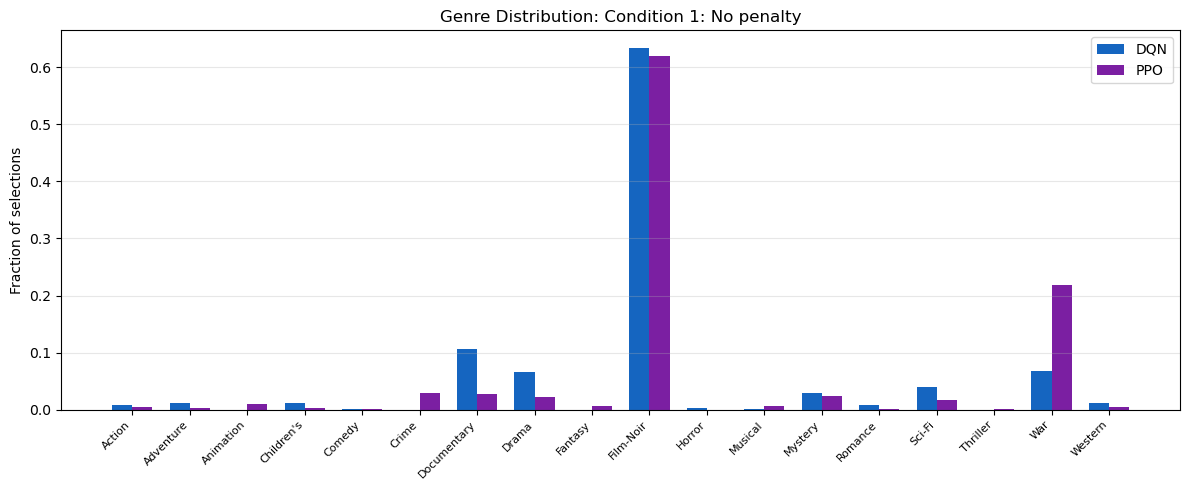

In [7]:
# CELL 3: Condition 1 — No penalty (GRU4Rec raw)
class EnvNoPenalty(FinalMovieRecEnvV6):
    """No fatigue penalty — raw GRU4Rec P(like) only."""

    def _dynamic_p(self, movieId):
        base_p = self.gru4rec_p_like(
            self.current_user, movieId, self.all_recommended)
        return float(np.clip(base_p, 0.1, 0.9))

env_no_penalty = EnvNoPenalty(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
exp1 = run_experiment(env_no_penalty, "Condition 1: No penalty")
plot_genre_comparison(exp1, save_path="exp1_no_penalty.png")

Output()


EXPERIMENT: Condition 2: Window penalty only
Training DQN (200k steps) ...


Output()

Training PPO (200k steps) ...


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 7.91 ± 2.53
  greedy    : 7.47 ± 2.67
  dqn       : 9.53 ± 2.72
  ppo       : 10.58 ± 2.32

FINAL COMPARISON — Condition 2: Window penalty only  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                 7.906 ± 2.527
Greedy-CTR             7.468 ± 2.669
DQN                    9.530 ± 2.717
PPO                   10.580 ± 2.319

DQN vs Random     : +1.624
DQN vs Greedy-CTR : +2.062  ← key metric
PPO vs Random     : +2.674
PPO vs Greedy-CTR : +3.112  ← key metric
[t-test] dqn vs greedy: t=12.096, p=0.0000 (significant)
[t-test] ppo vs greedy: t=19.665, p=0.0000 (significant)

  DQN genre distribution (top 5):
    Documentary    : 28.3%
    War            : 23.5%
    Film-Noir      : 17.4%
    Action         : 12.4%
    Animation      :  4.5%

  PPO genre distribution (top 5):
    Documentary    : 29.4%
    Film-Noir      : 27.9%
    War            : 11.6%
    Anima

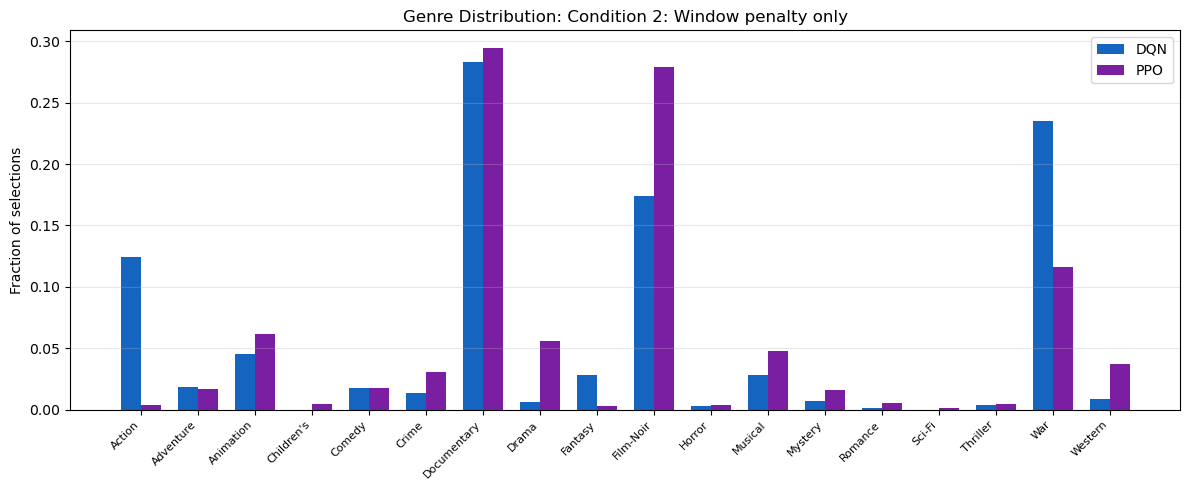

In [8]:
# CELL 4: Condition 2 — Window penalty only
class EnvWindowOnly(FinalMovieRecEnvV6):
    """Window penalty only — penalizes recent same-genre repetition."""

    def _dynamic_p(self, movieId):
        base_p = self.gru4rec_p_like(
            self.current_user, movieId, self.all_recommended)

        target_genres = set(self.movie_genres.get(movieId, []))
        recent = self.all_recommended[-self.window:]
        same_count = sum(1 for mid in recent
                         if target_genres & set(self.movie_genres.get(mid, [])))
        penalty = min(0.05 * same_count, 0.25)

        return float(np.clip(base_p - penalty, 0.1, 0.9))

env_window = EnvWindowOnly(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
exp2 = run_experiment(env_window, "Condition 2: Window penalty only")
plot_genre_comparison(exp2, save_path="exp2_window_only.png")

Output()


EXPERIMENT: Condition 3: Window + concentration penalty
Training DQN (200k steps) ...


Output()

Training PPO (200k steps) ...


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 7.77 ± 2.39
  greedy    : 5.72 ± 2.51
  dqn       : 9.73 ± 2.48
  ppo       : 9.96 ± 2.54

FINAL COMPARISON — Condition 3: Window + concentration penalty  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                 7.772 ± 2.386
Greedy-CTR             5.722 ± 2.509
DQN                    9.732 ± 2.484
PPO                    9.956 ± 2.540

DQN vs Random     : +1.960
DQN vs Greedy-CTR : +4.010  ← key metric
PPO vs Random     : +2.184
PPO vs Greedy-CTR : +4.234  ← key metric
[t-test] dqn vs greedy: t=25.368, p=0.0000 (significant)
[t-test] ppo vs greedy: t=26.487, p=0.0000 (significant)

  DQN genre distribution (top 5):
    Film-Noir      : 35.9%
    Musical        : 21.7%
    Documentary    : 17.2%
    War            :  7.8%
    Crime          :  5.8%

  PPO genre distribution (top 5):
    Film-Noir      : 30.9%
    Documentary    : 14.7%
    War            : 13.8%

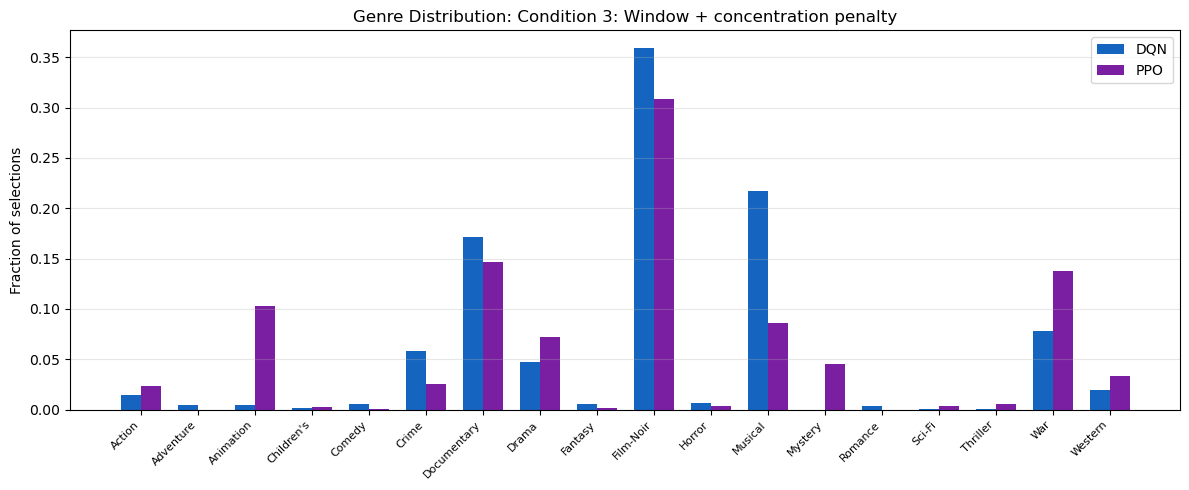

In [9]:
# CELL 5: Condition 3 — Window + concentration penalty (current)
# Uses the default FinalMovieRecEnvV6 which has both penalties
env_full = FinalMovieRecEnvV6(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
exp3 = run_experiment(env_full, "Condition 3: Window + concentration penalty")
plot_genre_comparison(exp3, save_path="exp3_window_concentration.png")

Output()


EXPERIMENT: Condition 4: Aggressive penalty
Training DQN (200k steps) ...


Output()

Training PPO (200k steps) ...


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 6.77 ± 2.24
  greedy    : 3.63 ± 1.80
  dqn       : 8.04 ± 2.82
  ppo       : 9.00 ± 2.59

FINAL COMPARISON — Condition 4: Aggressive penalty  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                 6.770 ± 2.239
Greedy-CTR             3.632 ± 1.802
DQN                    8.040 ± 2.819
PPO                    8.998 ± 2.594

DQN vs Random     : +1.270
DQN vs Greedy-CTR : +4.408  ← key metric
PPO vs Random     : +2.228
PPO vs Greedy-CTR : +5.366  ← key metric
[t-test] dqn vs greedy: t=29.429, p=0.0000 (significant)
[t-test] ppo vs greedy: t=37.946, p=0.0000 (significant)

  DQN genre distribution (top 5):
    War            : 21.2%
    Documentary    : 20.1%
    Film-Noir      : 16.9%
    Western        :  8.9%
    Children's     :  6.1%

  PPO genre distribution (top 5):
    Documentary    : 26.0%
    Film-Noir      : 25.6%
    Musical        : 11.6%
    War    

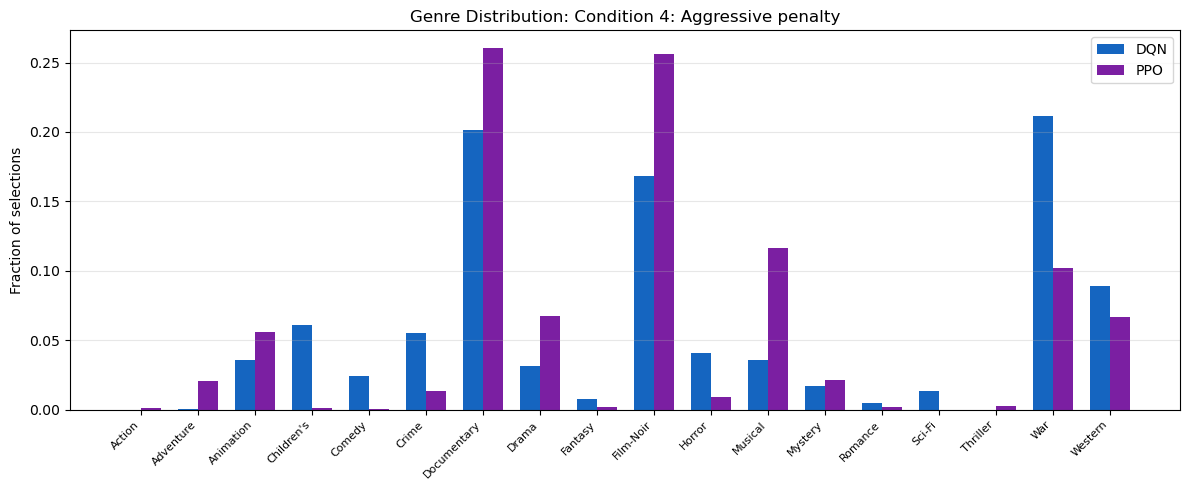

In [10]:
# CELL 6: Condition 4 — Aggressive penalty (tuning exploration)
class EnvAggressivePenalty(FinalMovieRecEnvV6):
    """Stronger penalties to force more diversity."""

    def _dynamic_p(self, movieId):
        base_p = self.gru4rec_p_like(
            self.current_user, movieId, self.all_recommended)

        target_genres = set(self.movie_genres.get(movieId, []))

        # Stronger window penalty
        recent = self.all_recommended[-self.window:]
        same_count = sum(1 for mid in recent
                         if target_genres & set(self.movie_genres.get(mid, [])))
        window_penalty = min(0.08 * same_count, 0.35)

        # Stronger concentration penalty with lower threshold
        if self.all_recommended:
            genre_picks = []
            for mid in self.all_recommended:
                genre_picks.extend(self.movie_genres.get(mid, []))
            total = len(genre_picks) if genre_picks else 1
            genre_frac = sum(1 for g in genre_picks if g in target_genres) / total
            concentration_penalty = 0.5 * max(genre_frac - 0.15, 0)
        else:
            concentration_penalty = 0

        penalty = window_penalty + concentration_penalty
        return float(np.clip(base_p - penalty, 0.1, 0.9))

env_aggressive = EnvAggressivePenalty(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
exp4 = run_experiment(env_aggressive, "Condition 4: Aggressive penalty")
plot_genre_comparison(exp4, save_path="exp4_aggressive.png")

Probing fatigue signal across conditions ...

No penalty               : P(like) k=0=0.489 → k=4=0.479  Δ=0.009
Window only              : P(like) k=0=0.445 → k=4=0.293  Δ=0.152
Window + concentration   : P(like) k=0=0.451 → k=4=0.223  Δ=0.228
Aggressive               : P(like) k=0=0.405 → k=4=0.115  Δ=0.289


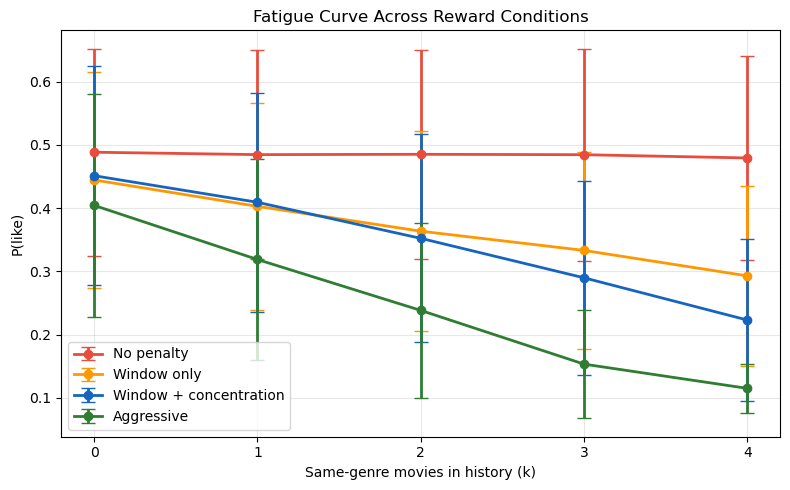

In [11]:
# CELL 7: Fatigue probe for each condition
print("Probing fatigue signal across conditions ...\n")

conditions = [
    ("No penalty", env_no_penalty),
    ("Window only", env_window),
    ("Window + concentration", env_full),
    ("Aggressive", env_aggressive),
]

fatigue_results = {}
for label, env in conditions:
    df = probe_fatigue_curve(env, ctx, n_users=30, n_targets_per_user=5, hist_len=4)
    summary = df.groupby("k_same_genre")["p_like"].agg(["mean", "std"]).reset_index()
    fatigue_results[label] = summary
    drop = summary["mean"].iloc[0] - summary["mean"].iloc[-1]
    print(f"{label:<25s}: P(like) k=0={summary['mean'].iloc[0]:.3f} → "
          f"k=4={summary['mean'].iloc[-1]:.3f}  Δ={drop:.3f}")

# Plot all fatigue curves together
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c", "#ff9800", "#1565c0", "#2e7d32"]
for (label, summary), color in zip(fatigue_results.items(), colors):
    ax.errorbar(summary["k_same_genre"], summary["mean"], yerr=summary["std"],
                marker="o", capsize=5, lw=2, markersize=6, label=label, color=color)

ax.set_xlabel("Same-genre movies in history (k)")
ax.set_ylabel("P(like)")
ax.set_title("Fatigue Curve Across Reward Conditions")
ax.set_xticks(range(5))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp_fatigue_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


CROSS-CONDITION SUMMARY (T=20, 500 episodes)
Condition               Random  Greedy     DQN     PPO  PPO-Greedy
---------------------------------------------------------------------------
No penalty                9.67   11.31   13.14   13.30       +1.99
Window only               7.91    7.47    9.53   10.58       +3.11
Window + conc.            7.77    5.72    9.73    9.96       +4.23
Aggressive                6.77    3.63    8.04    9.00       +5.37


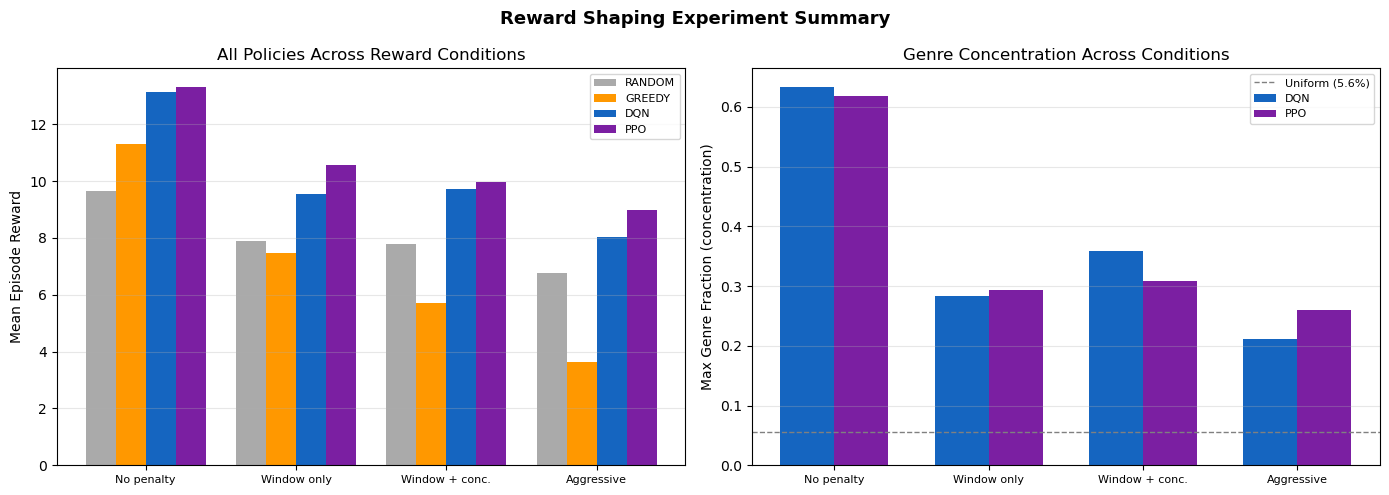

In [12]:
# CELL 8: Summary comparison across all conditions
all_experiments = [
    ("No penalty", exp1),
    ("Window only", exp2),
    ("Window + conc.", exp3),
    ("Aggressive", exp4),
]

# Summary table
print("\n" + "=" * 75)
print("CROSS-CONDITION SUMMARY (T=20, 500 episodes)")
print("=" * 75)
print(f"{'Condition':<22s} {'Random':>7s} {'Greedy':>7s} {'DQN':>7s} {'PPO':>7s} "
      f"{'PPO-Greedy':>11s}")
print("-" * 75)

summary_rows = []
for label, exp in all_experiments:
    r = exp["results"]
    row = {
        "condition": label,
        "random": np.mean(r["random"]),
        "greedy": np.mean(r["greedy"]),
        "dqn": np.mean(r["dqn"]),
        "ppo": np.mean(r["ppo"]),
        "ppo_vs_greedy": np.mean(r["ppo"]) - np.mean(r["greedy"]),
    }
    summary_rows.append(row)
    print(f"{label:<22s} {row['random']:7.2f} {row['greedy']:7.2f} "
          f"{row['dqn']:7.2f} {row['ppo']:7.2f} {row['ppo_vs_greedy']:+11.2f}")

# Bar chart: PPO reward across conditions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conditions_labels = [r["condition"] for r in summary_rows]
x = np.arange(len(conditions_labels))

# Left: All policies across conditions
w = 0.2
for i, (policy, color) in enumerate([
    ("random", "#aaaaaa"), ("greedy", "#ff9800"),
    ("dqn", "#1565c0"), ("ppo", "#7b1fa2")
]):
    vals = [r[policy] for r in summary_rows]
    axes[0].bar(x + i * w - 1.5 * w, vals, w, label=policy.upper(), color=color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions_labels, fontsize=8)
axes[0].set_ylabel("Mean Episode Reward")
axes[0].set_title("All Policies Across Reward Conditions")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Right: DQN genre concentration across conditions
# Measure using max genre fraction (higher = more concentrated)
dqn_max_frac = []
ppo_max_frac = []
for label, exp in all_experiments:
    dqn_vals = list(exp["genre_dists"]["DQN"].values())
    ppo_vals = list(exp["genre_dists"]["PPO"].values())
    dqn_max_frac.append(max(dqn_vals))
    ppo_max_frac.append(max(ppo_vals))

w = 0.35
axes[1].bar(x - w/2, dqn_max_frac, w, label="DQN", color="#1565c0")
axes[1].bar(x + w/2, ppo_max_frac, w, label="PPO", color="#7b1fa2")
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions_labels, fontsize=8)
axes[1].set_ylabel("Max Genre Fraction (concentration)")
axes[1].set_title("Genre Concentration Across Conditions")
axes[1].axhline(1/18, color="gray", ls="--", lw=1, label="Uniform (5.6%)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Reward Shaping Experiment Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
# CELL 9: Key takeaways
print("=" * 60)
print("KEY TAKEAWAYS")
print("=" * 60)

# Find best PPO condition
best_idx = max(range(len(summary_rows)), key=lambda i: summary_rows[i]["ppo"])
best = summary_rows[best_idx]
print(f"\n1. Best PPO performance: {best['condition']} "
      f"(reward={best['ppo']:.2f}, +{best['ppo_vs_greedy']:.2f} vs Greedy)")

# Compare concentration
print(f"\n2. DQN concentration (max genre fraction):")
for (label, _), frac in zip(all_experiments, dqn_max_frac):
    print(f"   {label:<22s}: {frac:.1%}")

print(f"\n3. PPO concentration (max genre fraction):")
for (label, _), frac in zip(all_experiments, ppo_max_frac):
    print(f"   {label:<22s}: {frac:.1%}")

print(f"\n4. Reward design impact:")
ppo_range = max(r["ppo"] for r in summary_rows) - min(r["ppo"] for r in summary_rows)
dqn_range = max(r["dqn"] for r in summary_rows) - min(r["dqn"] for r in summary_rows)
print(f"   PPO reward range across conditions: {ppo_range:.2f}")
print(f"   DQN reward range across conditions: {dqn_range:.2f}")
print(f"   → Reward shaping affects both agents substantially")

print(f"\n5. Structural insight:")
print(f"   DQN (deterministic) always concentrates — penalty design")
print(f"   cannot fully fix this. PPO (stochastic) naturally diversifies")
print(f"   and benefits more from well-designed penalties.")

KEY TAKEAWAYS

1. Best PPO performance: No penalty (reward=13.30, +1.99 vs Greedy)

2. DQN concentration (max genre fraction):
   No penalty            : 63.3%
   Window only           : 28.3%
   Window + conc.        : 35.9%
   Aggressive            : 21.2%

3. PPO concentration (max genre fraction):
   No penalty            : 61.9%
   Window only           : 29.4%
   Window + conc.        : 30.9%
   Aggressive            : 26.0%

4. Reward design impact:
   PPO reward range across conditions: 4.30
   DQN reward range across conditions: 5.10
   → Reward shaping affects both agents substantially

5. Structural insight:
   DQN (deterministic) always concentrates — penalty design
   cannot fully fix this. PPO (stochastic) naturally diversifies
   and benefits more from well-designed penalties.
